# LLVM Optimization Pipeline Performance Analysis

This notebook analyzes the empirical results of the LLVM pipeline from `-O0` to `-O1` in the `results` folder.
The goal is to evaluate: `speedup_vs_O0`, hardware contributions, compilation costs, IR impact, benchmark sensitivity, and diminishing returns.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from pathlib import Path

pio.renderers.default = 'notebook_connected'
sns.set(style='whitegrid', palette='viridis')
plt.rcParams.update({'figure.figsize': (12, 6), 'font.size': 12})

results_dir = Path('../results/run_20260407_161151')
main_csv = results_dir / 'main_20260407_161151.csv'
delta_csv = results_dir / 'incremental_deltas_20260407_161151.csv'

df_main = pd.read_csv(main_csv)
df_delta = pd.read_csv(delta_csv)

# Good practice filters: include only variants that compiled successfully if the column exists.
if 'compile_ok' in df_main.columns:
    df_main = df_main[df_main['compile_ok'] == True]  # noqa: E701

print('main rows:', len(df_main))
print('delta rows:', len(df_delta))


main rows: 294
delta rows: 294


## 1. Cumulative Speedup along the pipeline

Plot the cumulative `speedup_vs_O0` as a function of `variant_limit`. Statistically significant steps with medium-to-large effect size are highlighted.


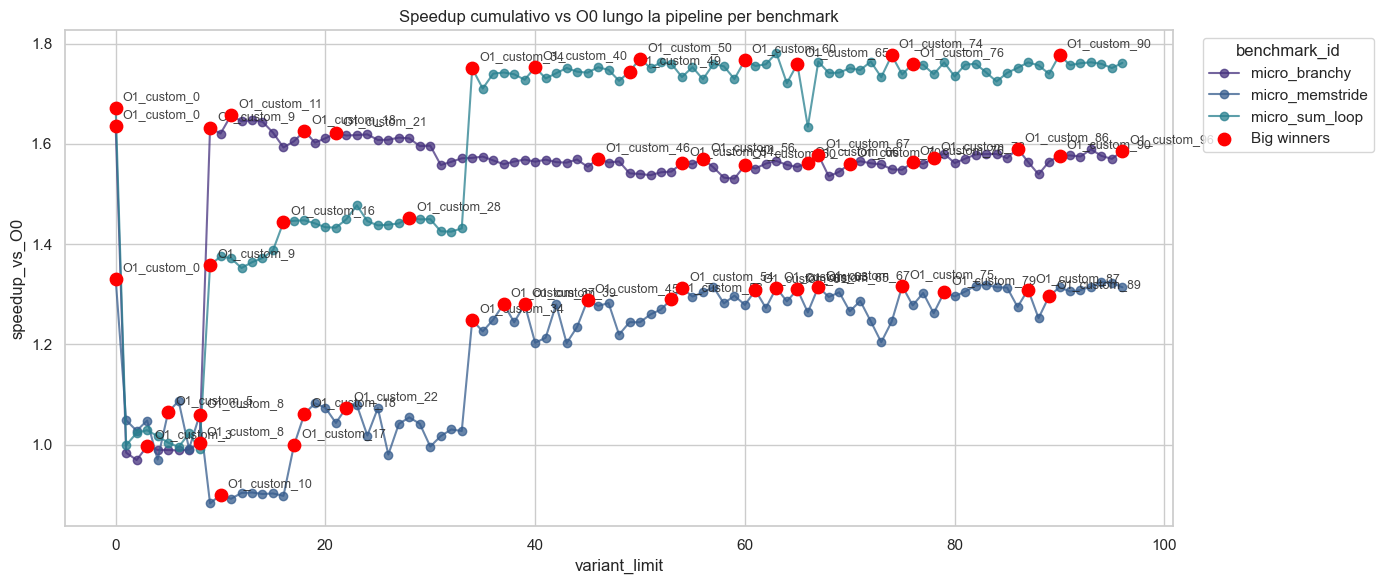

In [ ]:
df_speedup = df_main.copy()
numeric_cols = ['variant_limit', 'speedup_vs_O0', 'speedup_vs_prev', 'effect_size_vs_prev', 'pvalue_vs_prev']
for col in numeric_cols:
    df_speedup[col] = pd.to_numeric(df_speedup[col], errors='coerce')

df_speedup = df_speedup.sort_values(['benchmark_id', 'variant_limit'])

plt.figure(figsize=(14, 6))
for benchmark_id, group in df_speedup.groupby('benchmark_id'):
    plt.plot(group['variant_limit'], group['speedup_vs_O0'], marker='o', alpha=0.75, label=benchmark_id)

# Highlight the big winners based on the chosen criteria
significant = df_speedup[(df_speedup['pvalue_vs_prev'] < 0.05) & (df_speedup['effect_size_vs_prev'] > 0.4)]
plt.scatter(significant['variant_limit'], significant['speedup_vs_O0'], color='red', s=80, zorder=10, label='Big winners')
for _, row in significant.iterrows():
    plt.annotate(row['variant'], (row['variant_limit'], row['speedup_vs_O0']), xytext=(5, 5), textcoords='offset points', fontsize=9, alpha=0.85)

plt.title('Cumulative speedup vs O0 along the pipeline per benchmark')
plt.xlabel('variant_limit')
plt.ylabel('speedup_vs_O0')
plt.legend(title='benchmark_id', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


**Interpretation:** Steps with `pvalue_vs_prev < 0.05` and `effect_size_vs_prev > 0.4` mark points where the pipeline finds a robust, non-random improvement. These `big winners` define moments when LLVM significantly optimizes runtime relative to the previous variant.


## 2. Micro-architectural Impact: Correlation Heatmap

Analyze the correlation between `speedup_vs_prev` and hardware deltas including cache misses, branch misses, and backend stalls.


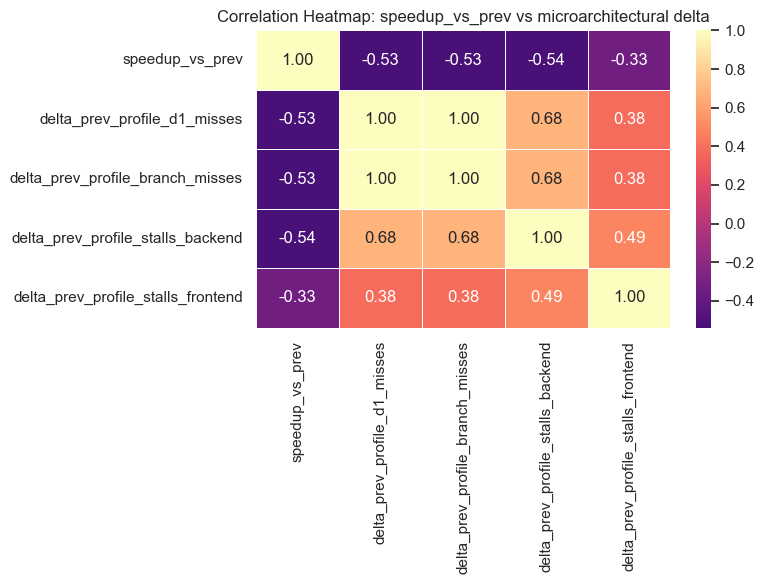

In [3]:
corr_cols = [
    'speedup_vs_prev',
    'delta_prev_profile_d1_misses',
    'delta_prev_profile_branch_misses',
    'delta_prev_profile_stalls_backend',
    'delta_prev_profile_stalls_frontend'
    ]
df_corr = df_speedup[corr_cols].copy()
for col in corr_cols:
    df_corr[col] = pd.to_numeric(df_corr[col], errors='coerce')
df_corr = df_corr.replace([np.inf, -np.inf], np.nan).dropna(how='all')
corr_matrix = df_corr.corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='magma', center=0, linewidths=0.5)
plt.title('Correlation Heatmap: speedup_vs_prev vs microarchitectural delta')
plt.tight_layout()
plt.show()

**Interpretation:** A negative correlation between `speedup_vs_prev` and `delta_prev_profile_stalls_backend` suggests the gain comes largely from reduced backend stalls. If instead the correlation is stronger with `delta_prev_profile_d1_misses`, it would indicate the improvement is mainly memory-access related.


## 3. Efficiency Frontier: Performance vs Compile Time

Scatter plot relating `opt` compilation time to the incremental runtime gain.


In [4]:
df_efficiency = df_speedup.copy()
df_efficiency['opt_wall_seconds'] = pd.to_numeric(df_efficiency['opt_wall_seconds'], errors='coerce')
df_efficiency = df_efficiency.dropna(subset=['opt_wall_seconds', 'speedup_vs_prev'])

fig = px.scatter(
    df_efficiency,
    x='opt_wall_seconds',
    y='speedup_vs_prev',
    color='benchmark_id',
    hover_data=['variant', 'variant_limit'],
    title='Efficiency Frontier: compile time vs incremental speedup',
    labels={
        'opt_wall_seconds': 'opt wall time (s)',
        'speedup_vs_prev': 'speedup vs previous variant'
    },
    log_x=True,
    height=600,
    width=900
)
fig.add_hline(y=1.0, line_dash='dash', line_color='gray', annotation_text='No incremental speedup', annotation_position='bottom right')
fig.show()

**Interpretation:** Points in the top right are expensive but effective passes. Points in the bottom right are `Cheap and Essential` candidates, while those on the left with low speedup may be optimized or removed if compilation budget is critical.


## 4. IR Complexity vs Runtime Performance

Comparison of static IR reduction with runtime instruction behavior; identify code expansion with reduced runtime.


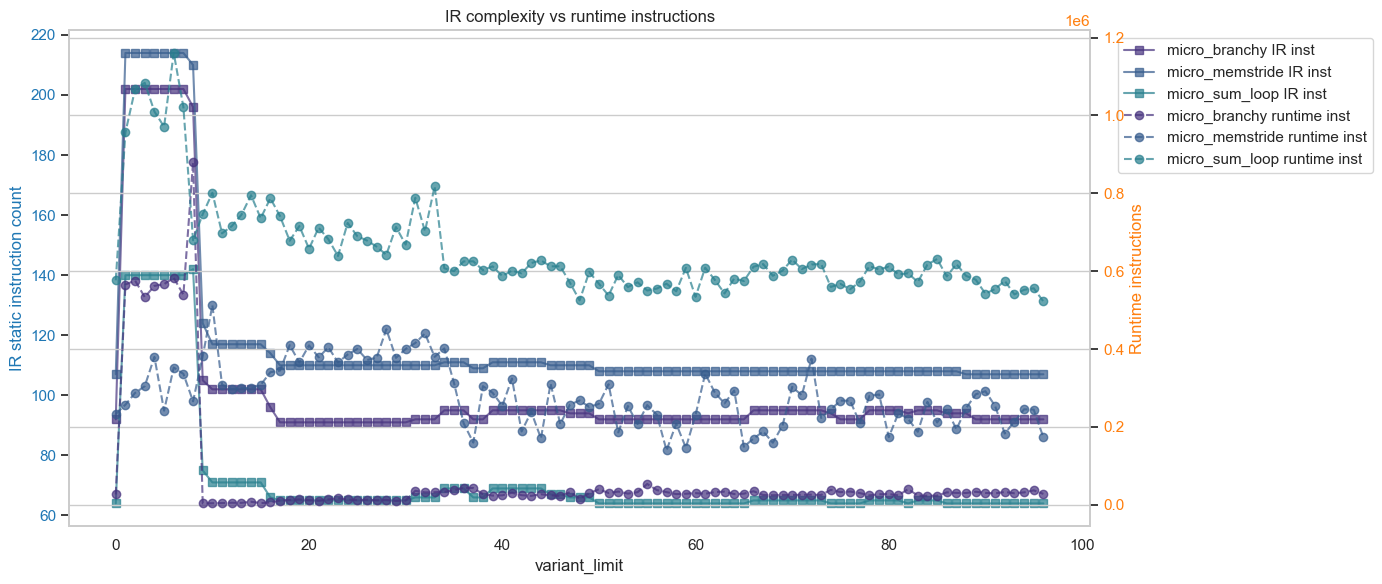

,benchmark_id,variant,variant_limit,delta_prev_binary_size_bytes,delta_prev_runtime_mean_seconds,speedup_vs_prev
1,micro_branchy,O1_custom_0,0.0,8.0,-0.220304,1.635601
99,micro_memstride,O1_custom_0,0.0,64.0,-0.013823,1.330867
197,micro_sum_loop,O1_custom_0,0.0,8.0,-0.094048,1.672189
207,micro_sum_loop,O1_custom_10,10.0,8.0,-0.002191,1.012884


In [5]:
df_ir = df_speedup.copy()
for col in ['ir_instruction_count', 'profile_instructions']:
    df_ir[col] = pd.to_numeric(df_ir[col], errors='coerce')

plt.figure(figsize=(14, 6))
ax1 = plt.gca()
ax2 = ax1.twinx()

grouped = df_ir.groupby('benchmark_id')
for benchmark_id, group in grouped:
    ax1.plot(group['variant_limit'], group['ir_instruction_count'], marker='s', label=f'{benchmark_id} IR inst', alpha=0.7)
    ax2.plot(group['variant_limit'], group['profile_instructions'], marker='o', linestyle='--', label=f'{benchmark_id} runtime inst', alpha=0.7)

ax1.set_xlabel('variant_limit')
ax1.set_ylabel('IR static instruction count', color='tab:blue')
ax2.set_ylabel('Runtime instructions', color='tab:orange')
plt.title('IR complexity vs runtime instructions')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:orange')
ax1.grid(False)
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

# Code expansion cases
df_expansion = df_ir[(pd.to_numeric(df_ir['delta_prev_binary_size_bytes'], errors='coerce') > 0) & (pd.to_numeric(df_ir['delta_prev_runtime_mean_seconds'], errors='coerce') < 0)]
df_expansion = df_expansion[['benchmark_id', 'variant', 'variant_limit', 'delta_prev_binary_size_bytes', 'delta_prev_runtime_mean_seconds', 'speedup_vs_prev']].copy()
df_expansion = df_expansion.sort_values('variant_limit')
df_expansion.head(10)

**Interpretation:** `Code Expansion` cases show LLVM can increase binary size while still reducing runtime. This is often a sign of optimizations like loop unrolling or predication that improve throughput despite larger code.


## 5. Benchmark Sensitivity (Stability Analysis)

Distribution of cumulative speedup per benchmark. This shows which workloads are more sensitive to the pipeline and which are more stable.


/var/folders/85/w1f_3bln5rzbljrg0v33t7880000gn/T/ipykernel_90347/1574580330.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_speedup, x='benchmark_id', y='speedup_vs_O0', palette='viridis')


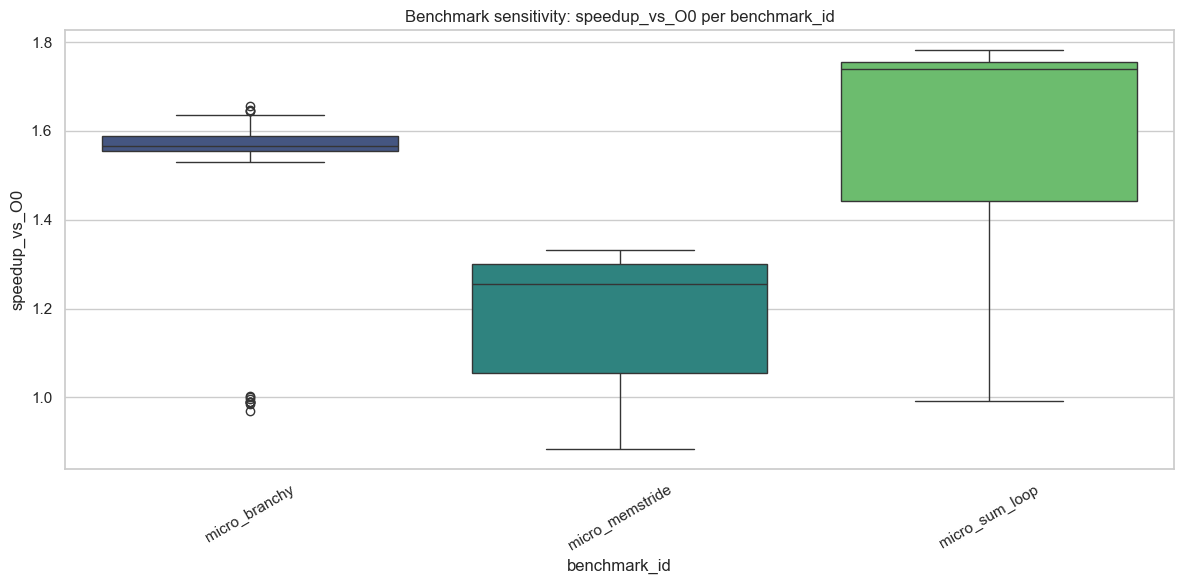

In [6]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_speedup, x='benchmark_id', y='speedup_vs_O0', palette='viridis')
plt.title('Benchmark sensitivity: speedup_vs_O0 per benchmark_id')
plt.xlabel('benchmark_id')
plt.ylabel('speedup_vs_O0')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Interpretation:** Benchmarks with wide box plots are more sensitive to the pass sequence, while narrow boxes suggest optimizations have a more limited and stable impact.


## 6. Diminishing Returns Analysis

Compute the derivatives of cumulative speedup and identify when 80% and 95% of the total `-O1` benefit are reached.


In [7]:
summary = []
for benchmark_id, group in df_speedup.groupby('benchmark_id'):
    g = group.sort_values('variant_limit').copy()
    g['speedup_vs_O0'] = pd.to_numeric(g['speedup_vs_O0'], errors='coerce')
    g = g.dropna(subset=['speedup_vs_O0'])
    if len(g) < 2:
        continue
    baseline = g['speedup_vs_O0'].iloc[0] if g['variant_limit'].iloc[0] == 0 else 1.0
    g['benefit'] = g['speedup_vs_O0'] - baseline
    total = g['benefit'].iloc[-1] if len(g) > 0 else np.nan
    if total <= 0 or np.isnan(total):
        continue
    g['fraction'] = g['benefit'] / total
    idx80 = g[g['fraction'] >= 0.80].iloc[0] if any(g['fraction'] >= 0.80) else g.iloc[-1]
    idx95 = g[g['fraction'] >= 0.95].iloc[0] if any(g['fraction'] >= 0.95) else g.iloc[-1]
    summary.append({
        'benchmark_id': benchmark_id,
        'variant_limit_80pct': int(idx80['variant_limit']),
        'variant_80pct': idx80['variant'],
        'variant_limit_95pct': int(idx95['variant_limit']),
        'variant_95pct': idx95['variant'],
        'final_speedup_vs_O0': g['speedup_vs_O0'].iloc[-1],
        'total_benefit': total
    })

summary_df = pd.DataFrame(summary)
summary_df

""


**Interpretation:** The point where 80% of the benefit is reached highlights the pipeline's `fast path`, while the remaining 15% toward 95% shows the `diminishing returns` steps. This is crucial for tradeoff decisions between compile time and runtime benefit.
